In [4]:
import pandas as pd
import numpy as np
from functools import reduce
import os

cad = pd.read_csv("data/CADUSD_daily_15y.csv", parse_dates=["Date"])
chf = pd.read_csv("data/CHFUSD_daily_15y.csv", parse_dates=["Date"])
eur = pd.read_csv("data/EURUSD_daily_15y.csv", parse_dates=["Date"])
gbp = pd.read_csv("data/GBPUSD_daily_15y.csv", parse_dates=["Date"])
jpy = pd.read_csv("data/JPYUSD_daily_15y.csv", parse_dates=["Date"])
sek = pd.read_csv("data/SEKUSD_daily_15y.csv", parse_dates=["Date"])
dxy = pd.read_csv("data/DXY_daily_15y.csv", parse_dates=["Date"]) 

dfs = {
    "CADUSD": cad,
    "CHFUSD": chf,
    "EURUSD": eur,
    "GBPUSD": gbp,
    "JPYUSD": jpy,
    "SEKUSD": sek,
    "DXY": dxy
}

In [5]:
def validate_df(name, df):
    print(f"\n=== Checking {name} ===")

    # A. Sort by date
    df.sort_values("Date", inplace=True)

    # B. Check date uniqueness
    dup = df["Date"].duplicated().sum()
    print(f"Duplicate dates: {dup}")

    # C. Check numeric columns
    non_numeric_cols = []
    for col in df.columns:
        if col != "Date":
            if not pd.api.types.is_numeric_dtype(df[col]):
                non_numeric_cols.append(col)
    print(f"Non-numeric columns: {non_numeric_cols}")

    # D. Check for accidental text values
    text_contamination = {}
    for col in df.columns:
        if col != "Date":
            mask = df[col].astype(str).str.contains("[A-Za-z]", regex=True)
            if mask.any():
                text_contamination[col] = df.loc[mask, col].unique().tolist()
    print(f"Text contamination: {text_contamination}")

    return df

In [6]:
for name, df in dfs.items():
    dfs[name] = validate_df(name, df)


=== Checking CADUSD ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}

=== Checking CHFUSD ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}

=== Checking EURUSD ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}

=== Checking GBPUSD ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}

=== Checking JPYUSD ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}

=== Checking SEKUSD ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}

=== Checking DXY ===
Duplicate dates: 0
Non-numeric columns: []
Text contamination: {}


In [7]:
merged = reduce(
    lambda left, right: pd.merge(left, right, on="Date", how="outer"),
    dfs.values()
)

merged.sort_values("Date", inplace=True)

In [8]:
missing_summary = merged.isna().sum()
print("\n=== Missing values per column ===")
print(missing_summary)


=== Missing values per column ===
Date          0
CADUSD=X      7
CHFUSD=X      9
EURUSD=X      6
GBPUSD=X      6
JPYUSD=X      6
SEKUSD=X      6
DX=F        139
dtype: int64


In [9]:
merged["missing_count"] = merged.drop(columns=["Date"]).isna().sum(axis=1)

rows_before = len(merged)
merged_clean = merged[merged["missing_count"] <= 3].copy()  # adjustable rule
rows_after = len(merged_clean)
rows_removed = rows_before - rows_after

merged_clean.drop(columns=["missing_count"], inplace=True)

print(f"\nRows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows removed: {rows_removed}")


Rows before: 3912
Rows after:  3906
Rows removed: 6


In [10]:
os.makedirs("data/processed", exist_ok=True)
merged_clean.to_csv("data/processed/master_price_panel.csv", index=False)

In [11]:
quality = {
    "rows_after_merge": rows_after,
    "start_date": merged_clean["Date"].min(),
    "end_date": merged_clean["Date"].max(),
    "duplicate_dates": merged_clean["Date"].duplicated().sum(),
    "rows_removed": rows_removed
}

# Missing per series
for col in merged_clean.columns:
    if col != "Date":
        quality[f"missing_{col}"] = merged_clean[col].isna().sum()

quality_df = pd.DataFrame([quality])

os.makedirs("outputs/phase1/tables", exist_ok=True)
quality_df.to_csv("outputs/phase1/tables/master_panel_data_quality.csv", index=False)

print("\n=== Quality summary saved ===")
print(quality_df)


=== Quality summary saved ===
   rows_after_merge start_date   end_date  duplicate_dates  rows_removed  \
0              3906 2010-12-20 2025-12-18                0             6   

   missing_CADUSD=X  missing_CHFUSD=X  missing_EURUSD=X  missing_GBPUSD=X  \
0                 1                 3                 1                 0   

   missing_JPYUSD=X  missing_SEKUSD=X  missing_DX=F  
0                 0                 0           139  


Step 2


In [12]:
# Load cleaned price panel
prices = pd.read_csv("data/processed/master_price_panel.csv", parse_dates=["Date"])

# Sort just in case
prices = prices.sort_values("Date")

# Compute simple returns
returns_raw = prices.copy()
for col in returns_raw.columns:
    if col != "Date":
        returns_raw[col] = returns_raw[col].pct_change()

C:\Users\Araj7\AppData\Local\Temp\ipykernel_32016\790404165.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_raw[col] = returns_raw[col].pct_change()


In [13]:
fx_cols = ["CADUSD=X", "CHFUSD=X", "EURUSD=X", "GBPUSD=X", "JPYUSD=X", "SEKUSD=X"]
dxy_col = "DX=F"


In [14]:
returns_usd = returns_raw.copy()

# Invert FX returns only
returns_usd[fx_cols] = -returns_usd[fx_cols]


In [15]:
os.makedirs("data/processed", exist_ok=True)
returns_raw.to_csv("data/processed/daily_returns_raw.csv", index=False)

returns_usd.to_csv("data/processed/daily_returns_usd_aligned.csv", index=False)

direction_map = pd.DataFrame({
    "asset": fx_cols + [dxy_col],
    "original_quote": ["USD per CAD", "USD per CHF", "USD per EUR", "USD per GBP", "USD per JPY", "USD per SEK", "USD index"],
    "transformation": ["multiply by -1"]*6 + ["unchanged"]
})

os.makedirs("outputs/phase1/tables", exist_ok=True)
direction_map.to_csv("outputs/phase1/tables/return_direction_map.csv", index=False)


In [16]:
corr = returns_usd[fx_cols + [dxy_col]].corr()[dxy_col]

corr_df = corr.to_frame(name="correlation_with_DXY")
corr_df.to_csv("outputs/phase1/tables/correlation_after_alignment.csv")


Step 3

In [17]:
# Load USD-direction aligned returns
returns = pd.read_csv("data/processed/daily_returns_usd_aligned.csv", parse_dates=["Date"])
returns = returns.sort_values("Date")

# Identify asset columns
asset_cols = [c for c in returns.columns if c != "Date"]

# Create output folder
os.makedirs("data/processed/return_layers", exist_ok=True)
os.makedirs("outputs/phase1/tables", exist_ok=True)
os.makedirs("outputs/phase1/graphs", exist_ok=True)

In [18]:
windows = {
    "1d": 1,
    "5d": 5,
    "10d": 10,
    "21d": 21,
    "63d": 63,
    "126d": 126,
    "252d": 252
}


In [19]:
def rolling_cumulative_return(series, window):
    return (1 + series).rolling(window).apply(np.prod, raw=True) - 1

In [20]:
summary_rows = []

for label, window in windows.items():
    df_layer = pd.DataFrame()
    df_layer["Date"] = returns["Date"]

    for col in asset_cols:
        df_layer[col] = rolling_cumulative_return(returns[col], window)

    # Save file
    out_path = f"data/processed/return_layers/returns_{label}.csv"
    df_layer.to_csv(out_path, index=False)

    # Build summary row
    valid = df_layer.dropna().shape[0]
    first_valid = df_layer.dropna()["Date"].min()
    last_valid = df_layer.dropna()["Date"].max()

    summary_rows.append({
        "horizon": label,
        "window_days": window,
        "rows_available": valid,
        "first_valid_date": first_valid,
        "last_valid_date": last_valid
    })

In [21]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("outputs/phase1/tables/return_layers_summary.csv", index=False)
summary_df


,horizon,window_days,rows_available,first_valid_date,last_valid_date
0,1d,1,3905,2010-12-21,2025-12-18
1,5d,5,3901,2010-12-27,2025-12-18
2,10d,10,3896,2011-01-03,2025-12-18
3,21d,21,3885,2011-01-18,2025-12-18
4,63d,63,3843,2011-03-17,2025-12-18
5,126d,126,3780,2011-06-15,2025-12-18
6,252d,252,3654,2011-12-08,2025-12-18


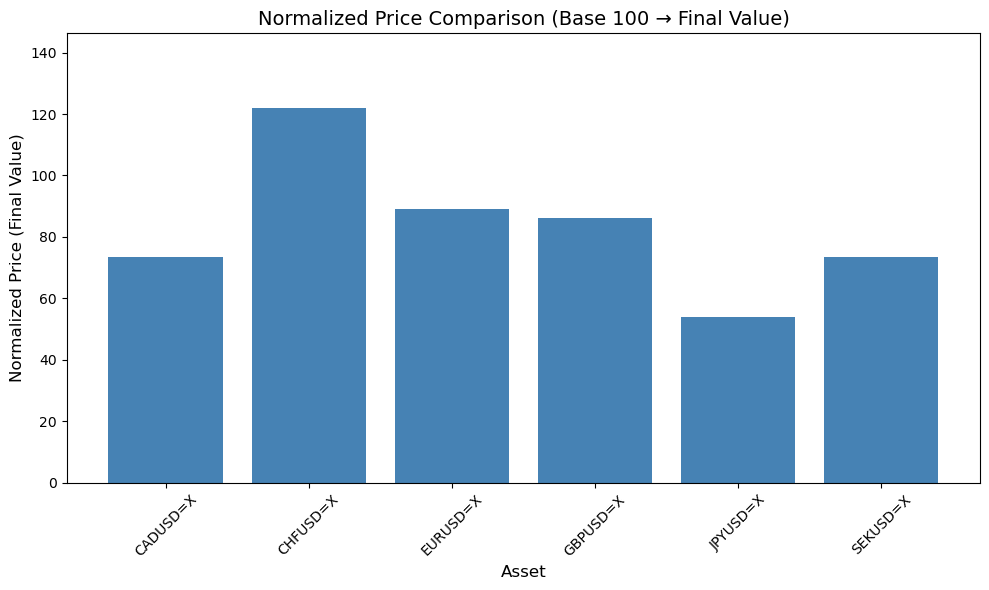

In [22]:
# === PHASE 1 — STEP 3: Diagnostic Plot 1 (Bar Plot Version) ===

import matplotlib.pyplot as plt
import pandas as pd

# prices is already loaded in this notebook
# asset_cols is already defined

# Normalize prices to base 100
prices_norm = prices.copy()
for col in asset_cols:
    prices_norm[col] = 100 * prices_norm[col] / prices_norm[col].iloc[0]

# Use the final normalized value for each asset
final_values = prices_norm.iloc[-1][asset_cols]

plt.figure(figsize=(10, 6))
plt.bar(asset_cols, final_values, color="steelblue")

plt.title("Normalized Price Comparison (Base 100 → Final Value)", fontsize=14)
plt.ylabel("Normalized Price (Final Value)", fontsize=12)
plt.xlabel("Asset", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(final_values) * 1.2)

plt.tight_layout()
plt.savefig("outputs/phase1/graphs/normalized_prices_base100.png")
#plt.close()



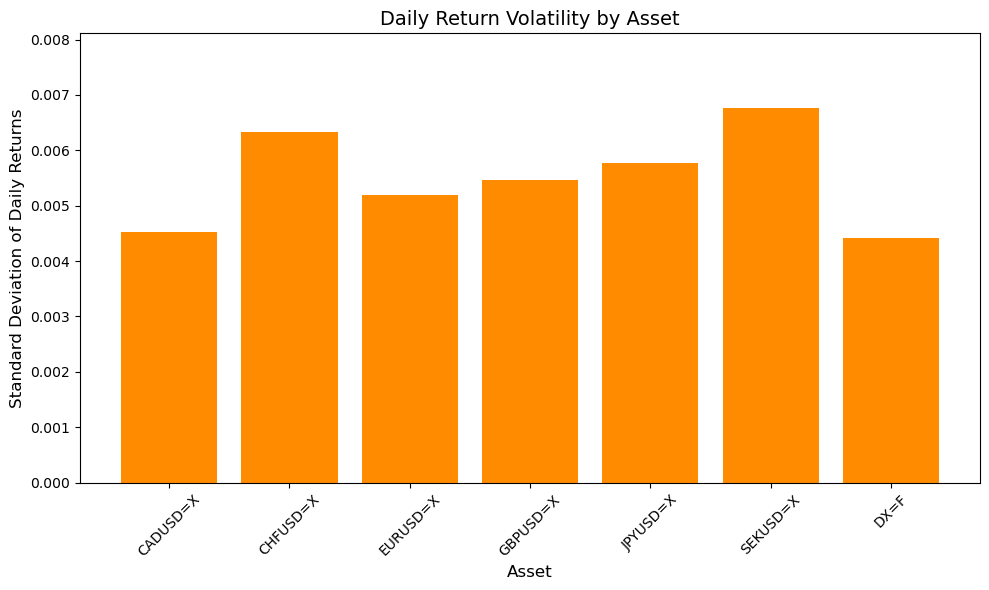

In [23]:


# returns is already loaded in this notebook
# asset_cols is already defined

# Compute volatility (std dev)
volatility = returns[asset_cols].std()

plt.figure(figsize=(10, 6))
plt.bar(asset_cols, volatility, color="darkorange")

plt.title("Daily Return Volatility by Asset", fontsize=14)
plt.ylabel("Standard Deviation of Daily Returns", fontsize=12)
plt.xlabel("Asset", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(volatility) * 1.2)

plt.tight_layout()
plt.savefig("outputs/phase1/graphs/return_distribution_daily.png")
#plt.close()

In [24]:
import yfinance as yf
import pandas as pd
from time import sleep

tickers = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "CADUSD": "CADUSD=X",
    "CHFUSD": "CHFUSD=X",
    "JPYUSD": "JPYUSD=X",
    "SEKUSD": "SEKUSD=X",
    "DXY": "DX-Y.NYB"     # correct ticker
}

start_date = "2010-12-01"
end_date   = "2025-12-31"

all_data = []

for name, ticker in tickers.items():

    print(f"Downloading {ticker}")

    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=False,
        progress=False
    )

    # retry once if failed
    if df.empty:
        print(f"Retrying {ticker}")
        sleep(2)

        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            interval="1d",
            auto_adjust=False,
            progress=False
        )

    df = df[["Open","High","Low","Close"]]

    df.columns = [
        f"{name}_Open",
        f"{name}_High",
        f"{name}_Low",
        f"{name}_Close"
    ]

    all_data.append(df)

# merge all pairs
ohlc_data = pd.concat(all_data, axis=1)

ohlc_data.reset_index(inplace=True)

# save file
ohlc_data.to_csv("fx_ohlc_2010_2025.csv", index=False)

print("\nSaved file: fx_ohlc_2010_2025.csv")
print(ohlc_data.head())


Saved file: fx_ohlc_2010_2025.csv
        Date  EURUSD_Open  EURUSD_High  EURUSD_Low  EURUSD_Close  GBPUSD_Open  \
0 2010-12-01     1.299495     1.313456    1.297707      1.299207     1.557147   
1 2010-12-02     1.312560     1.321196    1.306506      1.312491     1.561061   
2 2010-12-03     1.321301     1.337667    1.319505      1.321598     1.558992   
3 2010-12-06     1.341706     1.341976    1.325047      1.341598     1.576839   
4 2010-12-07     1.329045     1.339800    1.328374      1.328692     1.571117   

   GBPUSD_High  GBPUSD_Low  GBPUSD_Close  CADUSD_Open  ...  JPYUSD_Low  \
0     1.564798    1.555307      1.556808     0.975229  ...    0.011851   
1     1.566171    1.551518      1.561036     0.982415  ...    0.011855   
2     1.571388    1.558312      1.559090     0.996711  ...    0.011928   
3     1.577013    1.566097      1.576790     0.997606  ...    0.012052   
4     1.582404    1.570746      1.570870     0.994233  ...    0.012023   

   JPYUSD_Close  SEKUSD_Open  SEK

Phase 2 Step 1

In [56]:
import pandas as pd
import numpy as np
import os

# -----------------------------
# FOLDERS
# -----------------------------
base_processed = "data/processed"
layers_folder = f"{base_processed}/return_layers"
rankings_folder = f"{base_processed}/momentum_rankings"
strategy_folder = f"{base_processed}/strategies_top3_bottom3"
plots_folder = f"{strategy_folder}/plots"
ohlc_folder = f"{base_processed}/ohlc_daily"
final_summary_folder = f"{base_processed}/final_summary"

os.makedirs(rankings_folder, exist_ok=True)
os.makedirs(strategy_folder, exist_ok=True)
os.makedirs(plots_folder, exist_ok=True)
os.makedirs(ohlc_folder, exist_ok=True)
os.makedirs(final_summary_folder, exist_ok=True)

# -----------------------------
# FX PAIRS
# -----------------------------
fx_cols = ["CADUSD=X", "CHFUSD=X", "EURUSD=X", "GBPUSD=X", "JPYUSD=X", "SEKUSD=X"]
dxy_col = "DX=F"   # if your aligned return file uses a different name, change it here

# -----------------------------
# HORIZONS
# readable_name : (file_name, lookback_days)
# -----------------------------
horizons = {
    "Daily": ("returns_1d.csv", 1),
    "Weekly": ("returns_5d.csv", 5),
    "Biweekly": ("returns_10d.csv", 10),
    "Monthly": ("returns_21d.csv", 21),
    "Quarterly": ("returns_63d.csv", 63),
    "Semi-Annual": ("returns_126d.csv", 126),
    "Annual": ("returns_252d.csv", 252)
}

In [57]:
def build_rankings_for_horizon(horizon_name, filename):
    path = f"{layers_folder}/{filename}"
    df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date")

    df_fx = df[["Date"] + fx_cols].copy()

    returns_only = df_fx[fx_cols]
    ranks = returns_only.rank(axis=1, method="first", ascending=False)

    ranks.columns = [f"{c}_rank" for c in ranks.columns]

    rankings_out = pd.concat([df_fx[["Date"]], ranks], axis=1)

    out_path = f"{rankings_folder}/rankings_{horizon_name}.csv"
    rankings_out.to_csv(out_path, index=False)

    return rankings_out

# run for all horizons
all_rankings = {}

for horizon_name, (filename, L) in horizons.items():
    print(f"Building rankings for horizon: {horizon_name}")
    rankings = build_rankings_for_horizon(horizon_name, filename)
    all_rankings[horizon_name] = rankings

Building rankings for horizon: Daily
Building rankings for horizon: Weekly
Building rankings for horizon: Biweekly
Building rankings for horizon: Monthly
Building rankings for horizon: Quarterly
Building rankings for horizon: Semi-Annual
Building rankings for horizon: Annual


In [58]:
def compute_sharpe(return_series, annualization=252):
    s = pd.Series(return_series).copy()
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) < 2:
        return np.nan

    std = s.std(ddof=1)
    mean = s.mean()

    if pd.isna(std) or std == 0:
        return np.nan

    return (mean / std) * np.sqrt(annualization)

In [59]:
# load aligned daily returns
returns_usd = pd.read_csv(f"{base_processed}/daily_returns_usd_aligned.csv", parse_dates=["Date"])
returns_usd = returns_usd.sort_values("Date").reset_index(drop=True)

# -----------------------------
# BUY & HOLD ON DXY
# -----------------------------
buyhold_df = returns_usd[["Date", dxy_col]].copy()
buyhold_df[dxy_col] = pd.to_numeric(buyhold_df[dxy_col], errors="coerce").fillna(0)

buyhold_df["buyhold_portfolio_value"] = 100 * (1 + buyhold_df[dxy_col]).cumprod()
buyhold_df["buyhold_cumulative_return"] = buyhold_df["buyhold_portfolio_value"] / 100 - 1
buyhold_df["buyhold_roll_max"] = buyhold_df["buyhold_portfolio_value"].cummax()
buyhold_df["buyhold_drawdown"] = buyhold_df["buyhold_portfolio_value"] / buyhold_df["buyhold_roll_max"] - 1

buyhold_sharpe = compute_sharpe(buyhold_df[dxy_col], annualization=252)

buyhold_final_portfolio_value = float(buyhold_df["buyhold_portfolio_value"].iloc[-1])
buyhold_final_cum_return = float(buyhold_df["buyhold_cumulative_return"].iloc[-1])
buyhold_max_drawdown = float(buyhold_df["buyhold_drawdown"].min())

# save benchmark time series too
buyhold_df.to_csv(f"{strategy_folder}/buyhold_dxy.csv", index=False)


In [60]:
def build_top_bottom_weights(returns_df, rankings_df, L):
    df = returns_df.merge(rankings_df, on="Date", how="inner").reset_index(drop=True)

    rank_cols = [f"{c}_rank" for c in fx_cols]
    df[rank_cols] = df[rank_cols].apply(pd.to_numeric, errors="coerce")

    n = len(df)
    dates = df["Date"]

    w_top = pd.DataFrame(0.0, index=range(n), columns=fx_cols)
    w_bot = pd.DataFrame(0.0, index=range(n), columns=fx_cols)

    valid_mask = df[rank_cols].notna().all(axis=1)
    if not valid_mask.any():
        return dates, w_top, w_bot

    first_valid_idx = valid_mask[valid_mask].index[0]

    # signal formed on signal_idx, traded from signal_idx+1 onward
    for signal_idx in range(first_valid_idx, n - 1, L):
        row = df.loc[signal_idx, rank_cols]
        ranks = pd.to_numeric(row, errors="coerce")
        ranks.index = fx_cols

        if ranks.isna().any():
            continue

        top3 = ranks.nsmallest(3).index.tolist()
        bot3 = ranks.nlargest(3).index.tolist()

        hold_start = signal_idx + 1
        hold_end = min(signal_idx + L + 1, n)   # exclusive

        w_top.loc[hold_start:hold_end - 1, top3] = 1/3
        w_bot.loc[hold_start:hold_end - 1, bot3] = 1/3

    return dates, w_top, w_bot


In [61]:
strategy_summaries = []

for horizon_name, (filename, L) in horizons.items():
    print(f"Building Top3/Bottom3 strategy for horizon {horizon_name} (L={L})")

    rankings_path = f"{rankings_folder}/rankings_{horizon_name}.csv"
    rankings = pd.read_csv(rankings_path, parse_dates=["Date"]).sort_values("Date")

    dates, w_top, w_bot = build_top_bottom_weights(
        returns_df=returns_usd[["Date"] + fx_cols],
        rankings_df=rankings,
        L=L
    )

    ret_fx = returns_usd.set_index("Date").loc[dates, fx_cols].reset_index(drop=True)

    # daily strategy returns
    top3_ret = (w_top.values * ret_fx.values).sum(axis=1)
    bot3_ret = (w_bot.values * ret_fx.values).sum(axis=1)

    # portfolio values (base 100)
    top3_value = 100 * (1 + pd.Series(top3_ret)).cumprod()
    bot3_value = 100 * (1 + pd.Series(bot3_ret)).cumprod()

    # cumulative returns
    top3_cum = top3_value / 100 - 1
    bot3_cum = bot3_value / 100 - 1

    # drawdowns
    top3_roll_max = top3_value.cummax()
    bot3_roll_max = bot3_value.cummax()

    top3_dd = top3_value / top3_roll_max - 1
    bot3_dd = bot3_value / bot3_roll_max - 1

    top3_sharpe = compute_sharpe(top3_ret, annualization=252)
    bot3_sharpe = compute_sharpe(bot3_ret, annualization=252)

    # save full time series
    df_top = pd.DataFrame({
        "Date": dates,
        "top3_daily_return": top3_ret,
        "top3_portfolio_value": top3_value,
        "top3_cumulative_return": top3_cum,
        "top3_drawdown": top3_dd
    })

    df_bot = pd.DataFrame({
        "Date": dates,
        "bottom3_daily_return": bot3_ret,
        "bottom3_portfolio_value": bot3_value,
        "bottom3_cumulative_return": bot3_cum,
        "bottom3_drawdown": bot3_dd
    })

    df_top.to_csv(f"{strategy_folder}/top3_{horizon_name}.csv", index=False)
    df_bot.to_csv(f"{strategy_folder}/bottom3_{horizon_name}.csv", index=False)

    # summary row
    strategy_summaries.append({
        "horizon": horizon_name,
        "lookback_days": L,

        "buyhold_final_portfolio_value": buyhold_final_portfolio_value,
        "buyhold_final_cum_return": buyhold_final_cum_return,
        "buyhold_sharpe": buyhold_sharpe,
        "buyhold_max_drawdown": buyhold_max_drawdown,

        "top3_final_portfolio_value": float(top3_value.iloc[-1]),
        "top3_final_cum_return": float(top3_cum.iloc[-1]),
        "top3_sharpe": float(top3_sharpe) if pd.notna(top3_sharpe) else np.nan,
        "top3_max_drawdown": float(top3_dd.min()),

        "bottom3_final_portfolio_value": float(bot3_value.iloc[-1]),
        "bottom3_final_cum_return": float(bot3_cum.iloc[-1]),
        "bottom3_sharpe": float(bot3_sharpe) if pd.notna(bot3_sharpe) else np.nan,
        "bottom3_max_drawdown": float(bot3_dd.min())
    })

summary_df = pd.DataFrame(strategy_summaries)

horizon_order = ["Daily", "Weekly", "Biweekly", "Monthly", "Quarterly", "Semi-Annual", "Annual"]
summary_df["horizon"] = pd.Categorical(summary_df["horizon"], categories=horizon_order, ordered=True)
summary_df = summary_df.sort_values("horizon").reset_index(drop=True)

summary_df.to_csv(f"{strategy_folder}/strategy_summary_top3_bottom3.csv", index=False)
summary_df


Building Top3/Bottom3 strategy for horizon Daily (L=1)
Building Top3/Bottom3 strategy for horizon Weekly (L=5)
Building Top3/Bottom3 strategy for horizon Biweekly (L=10)
Building Top3/Bottom3 strategy for horizon Monthly (L=21)
Building Top3/Bottom3 strategy for horizon Quarterly (L=63)
Building Top3/Bottom3 strategy for horizon Semi-Annual (L=126)
Building Top3/Bottom3 strategy for horizon Annual (L=252)


,horizon,lookback_days,buyhold_final_portfolio_value,buyhold_final_cum_return,buyhold_sharpe,buyhold_max_drawdown,top3_final_portfolio_value,top3_final_cum_return,top3_sharpe,top3_max_drawdown,bottom3_final_portfolio_value,bottom3_final_cum_return,bottom3_sharpe,bottom3_max_drawdown
0,Daily,1,121.03196,0.21032,0.210746,-0.156067,75.553244,-0.244468,-0.213718,-0.260586,165.265386,0.652654,0.480963,-0.136204
1,Weekly,5,121.03196,0.21032,0.210746,-0.156067,102.996620,0.029966,0.062445,-0.186936,121.668411,0.216684,0.210253,-0.153507
2,Biweekly,10,121.03196,0.21032,0.210746,-0.156067,88.834478,-0.111655,-0.065207,-0.183904,147.111722,0.471117,0.387381,-0.134575
3,Monthly,21,121.03196,0.21032,0.210746,-0.156067,111.950691,0.119507,0.135812,-0.198212,115.442345,0.154423,0.164248,-0.141070
4,Quarterly,63,121.03196,0.21032,0.210746,-0.156067,124.366724,0.243667,0.231029,-0.160986,111.155352,0.111554,0.131621,-0.162924
5,Semi-Annual,126,121.03196,0.21032,0.210746,-0.156067,122.401371,0.224014,0.219005,-0.195385,119.708157,0.197082,0.198992,-0.173578
6,Annual,252,121.03196,0.21032,0.210746,-0.156067,116.834931,0.168349,0.183334,-0.167627,116.603509,0.166035,0.179957,-0.161453


In [62]:
import matplotlib.pyplot as plt

summary = pd.read_csv(f"{strategy_folder}/strategy_summary_top3_bottom3.csv")

horizon_order = ["Daily", "Weekly", "Biweekly", "Monthly", "Quarterly", "Semi-Annual", "Annual"]
summary["horizon"] = pd.Categorical(summary["horizon"], categories=horizon_order, ordered=True)
summary = summary.sort_values("horizon").reset_index(drop=True)

x = np.arange(len(summary))
width = 0.25

# ---------------------------------
# 1) FINAL PORTFOLIO VALUE
# ---------------------------------
plt.figure(figsize=(12, 6))
plt.bar(x - width, summary["buyhold_final_portfolio_value"], width=width, color="red", label="Buy & Hold")
plt.bar(x, summary["top3_final_portfolio_value"], width=width, color="green", label="Top 3")
plt.bar(x + width, summary["bottom3_final_portfolio_value"], width=width, color="blue", label="Bottom 3")

plt.title("Top 3 / Bottom 3 vs DXY Buy & Hold (Start = $100)")
plt.xlabel("Time Periods")
plt.ylabel("Portfolio Value ($)")
plt.xticks(x, summary["horizon"])
plt.ylim(bottom=0)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{plots_folder}/grouped_final_portfolio_value.png", dpi=300)
plt.close()

# ---------------------------------
# 2) SHARPE RATIO
# ---------------------------------
plt.figure(figsize=(12, 6))
plt.bar(x - width, summary["buyhold_sharpe"], width=width, color="red", label="Buy & Hold")
plt.bar(x, summary["top3_sharpe"], width=width, color="green", label="Top 3")
plt.bar(x + width, summary["bottom3_sharpe"], width=width, color="blue", label="Bottom 3")

plt.title("Top 3 / Bottom 3 vs DXY Buy & Hold Sharpe Ratio")
plt.xlabel("Time Periods")
plt.ylabel("Sharpe Ratio")
plt.xticks(x, summary["horizon"])

ymin = min(
    0,
    np.nanmin(summary["buyhold_sharpe"]),
    np.nanmin(summary["top3_sharpe"]),
    np.nanmin(summary["bottom3_sharpe"])
)
plt.ylim(bottom=ymin)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{plots_folder}/grouped_sharpe_ratio.png", dpi=300)
plt.close()

# ---------------------------------
# 3) MAX DRAWDOWN MAGNITUDE
# ---------------------------------
summary["buyhold_drawdown_mag"] = summary["buyhold_max_drawdown"].abs()
summary["top3_drawdown_mag"] = summary["top3_max_drawdown"].abs()
summary["bottom3_drawdown_mag"] = summary["bottom3_max_drawdown"].abs()

plt.figure(figsize=(12, 6))
plt.bar(x - width, summary["buyhold_drawdown_mag"], width=width, color="red", label="Buy & Hold")
plt.bar(x, summary["top3_drawdown_mag"], width=width, color="green", label="Top 3")
plt.bar(x + width, summary["bottom3_drawdown_mag"], width=width, color="blue", label="Bottom 3")

plt.title("Top 3 / Bottom 3 vs DXY Buy & Hold Max Drawdown Magnitude")
plt.xlabel("Time Periods")
plt.ylabel("Drawdown Magnitude")
plt.xticks(x, summary["horizon"])
plt.ylim(bottom=0)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{plots_folder}/grouped_max_drawdown_magnitude.png", dpi=300)
plt.close()

print("Plots saved successfully.")

Plots saved successfully.
